# Regime-Stratified Sensitivity Analysis — Level 5L6

Sensitivity of the L5L6 model **conditioned on the rate-limiting regime**
(surface- / oxide- / metal-limited), where **regime = argmax of the flux-weighted
resistance fractions** (`frac_surface`, `frac_oxide`, `frac_metal`).

**Method (Option A — targeted per-regime sampling):**
- **Phase 1:** one LHS scan per regime over a regime-favouring *preset* → label by
  argmax → keep the in-regime cluster.
- **Phase 2 Route B (primary):** given-data **PAWN** + **Borgonovo-δ** on the *true*
  cluster — valid on scattered points, zero extra model evaluations.
- **Phase 2 Route A (secondary):** **accept-and-report** Saltelli S1/ST over each
  regime's top-k percentile **sub-box** (off-regime contamination reported).
- Heavy-tailed metrics (`flux`, `permeability`) analysed on **log10**; `theta` linear.

**Data is cached to CSV** (see `RESULTS_DIR`): the first run saves all model
evaluations and result tables; later runs **reload** them and skip the expensive
model calls. Set `FORCE_RECOMPUTE = True` (or delete `RESULTS_DIR`) to regenerate.

See [docs/regime_sensitivity_workflow.md](../docs/regime_sensitivity_workflow.md).
Run with the **`mace_env`** kernel.

In [1]:
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

# repo root on path (mirrors the other notebooks)
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
import validation.sensitivity_level1 as sens
importlib.reload(sens)
from validation.sensitivity_level1 import (
    SUGGESTED_RANGES_LEVEL5L6, REGIME_PRESETS, DEFAULT_N_PER_REGIME, REGIME_SA_METRICS,
    run_targeted_regime_scans, load_regime_scans, plot_regime_exploration,
    morris_screen_global, rank_and_select_top_k,
    givendata_sensitivity_by_regime, summarize_givendata, plot_givendata_results,
    sobol_regime_subbox, plot_sobol_results, contamination_summary, summarize_route_a,
    regime_comparison_matrix, plot_regime_comparison_heatmap, plot_route_a
)
PARAMS = list(SUGGESTED_RANGES_LEVEL5L6.keys())
print(f"{len(PARAMS)} parameters; regime presets: {list(REGIME_PRESETS)}")

36 parameters; regime presets: ['metal', 'surface', 'oxide']


In [3]:
# === Run configuration (scale these up for a production run) ==================
SEED            = 42
N_PER_REGIME    = {'metal': 1000, 'surface': 2500, 'oxide': 5000}  # LHS draws per preset
MORRIS_TRAJ     = 256        # global Morris screen trajectories
SOBOL_N         = 256        # Route A Saltelli base samples (per regime)
TOP_K           = 8          # params kept for ranking / Route A sub-box
METRICS         = ['flux', 'permeability', 'theta']

# === Data caching =============================================================
RESULTS_DIR     = "sa_results"     # all CSV outputs live here
FORCE_RECOMPUTE = False            # True (or delete RESULTS_DIR) to recompute from scratch
SCAN_DIR        = os.path.join(RESULTS_DIR, "scans")
os.makedirs(SCAN_DIR, exist_ok=True)

def cache_path(name):
    """Path under RESULTS_DIR; removed first if FORCE_RECOMPUTE so the step recomputes."""
    p = os.path.join(RESULTS_DIR, name)
    if FORCE_RECOMPUTE and os.path.exists(p):
        os.remove(p)
    return p
print("results dir:", os.path.abspath(RESULTS_DIR), "| FORCE_RECOMPUTE =", FORCE_RECOMPUTE)

results dir: /Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/Fuerst_et_al_2024/sa_results | FORCE_RECOMPUTE = False


## Phase 1 — Targeted per-regime scans (cached)

If the scan CSVs already exist they are reloaded (no model calls); otherwise the
scans run and are saved to `RESULTS_DIR/scans/scan_<regime>.csv`.

In [4]:
scan_files = [os.path.join(SCAN_DIR, f"scan_{r}.csv") for r in ('metal', 'surface', 'oxide')]

if (not FORCE_RECOMPUTE) and all(os.path.exists(p) for p in scan_files):
    print("Loading cached scans from", SCAN_DIR)
    clusters, scans, master = load_regime_scans(SCAN_DIR)
    yields = {r: clusters[r].shape[0] / scans[r].shape[0] for r in clusters}
else:
    clusters, scans, master, yields = run_targeted_regime_scans(
        N_per_regime=N_PER_REGIME, seed=SEED, save_dir=SCAN_DIR, verbose=True)

print("\nCluster sizes:", {k: len(v) for k, v in clusters.items()})
print("Yields:", {k: f"{v*100:.1f}%" for k, v in yields.items()})

# Save the combined in-regime table
master.to_csv(os.path.join(RESULTS_DIR, "master_clusters.csv"), index=False)
print("\nMedian outputs by regime:")
print(master.groupby('regime')[['flux', 'permeability', 'theta']].median().to_string())


--- targeted scan: metal (N=1000) ---
  saved scan -> sa_results/scans/scan_metal.csv
  yield: 825/1000 in-regime (82.5%)

--- targeted scan: surface (N=2500) ---
  saved scan -> sa_results/scans/scan_surface.csv
  yield: 732/2500 in-regime (29.3%)

--- targeted scan: oxide (N=5000) ---
  saved scan -> sa_results/scans/scan_oxide.csv
  yield: 3751/5000 in-regime (75.0%)

Cluster sizes: {'metal': 825, 'surface': 732, 'oxide': 3751}
Yields: {'metal': '82.5%', 'surface': '29.3%', 'oxide': '75.0%'}

Median outputs by regime:
                 flux  permeability     theta
regime                                       
metal    8.290686e-06  1.557772e-14  0.375981
oxide    2.111534e-08  3.379479e-17  0.379321
surface  2.978285e-09  1.300678e-13  0.000026


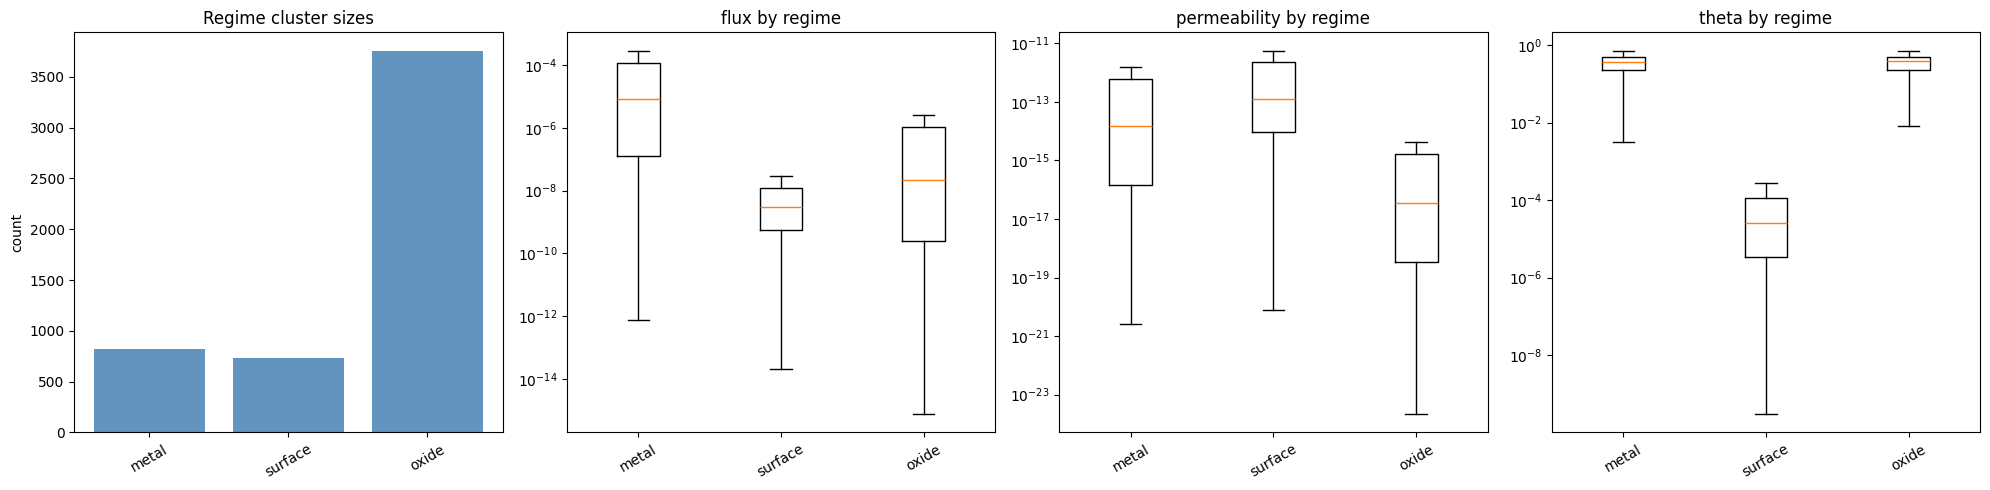


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting  metal  mixed  oxide  surface
regime                                            
metal                  2305   1251     60        7
oxide                     0    744   3401        0
surface                  33    274      1      424


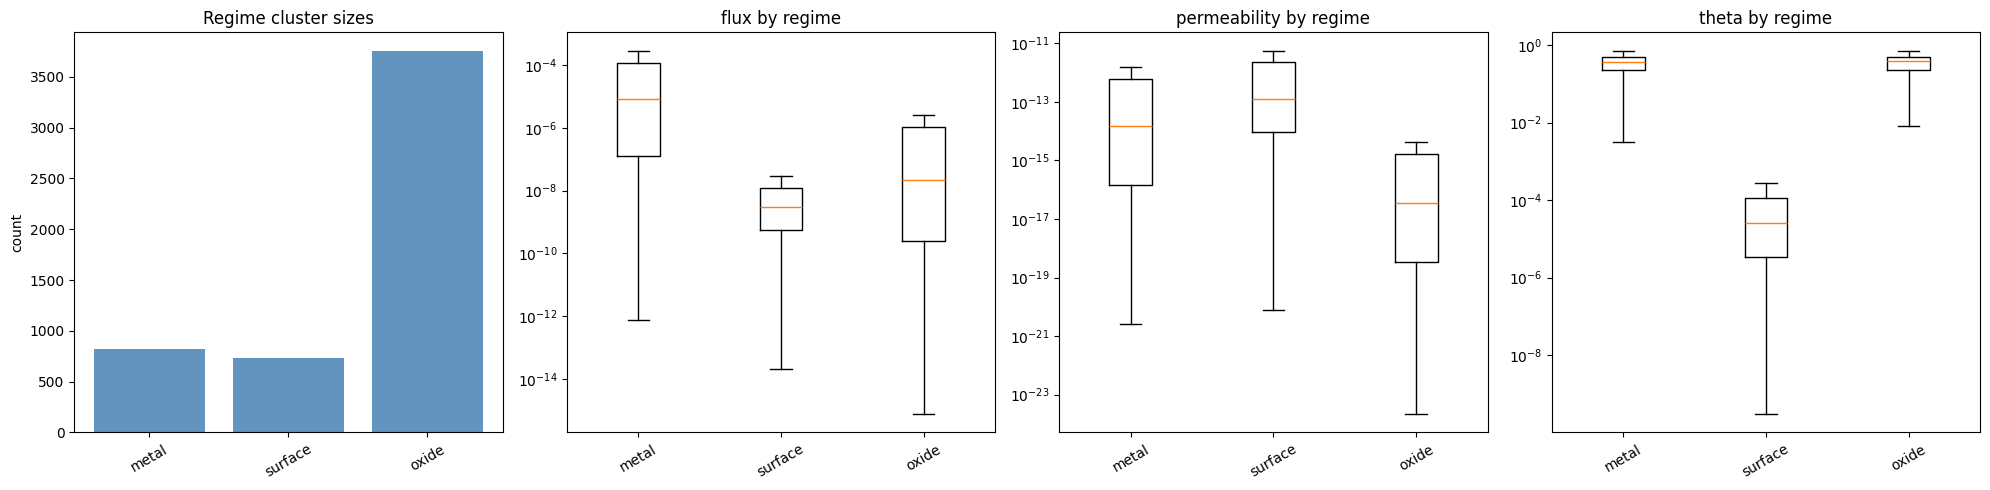

In [5]:
full_scan = pd.concat(scans.values(), ignore_index=True)
plot_regime_exploration(clusters, output_metrics=('flux', 'permeability', 'theta'),
                        scan_df=full_scan)

## Phase 1 (screen) — Global Morris over all 40 params (cached)

Evaluations cached to `RESULTS_DIR/morris_evals.csv`; the ranking is saved to
`RESULTS_DIR/morris_ranking.csv`.

In [6]:
screen = morris_screen_global(SUGGESTED_RANGES_LEVEL5L6, output_metrics=METRICS,
                              N_trajectories=MORRIS_TRAJ, seed=SEED,
                              cache_csv=cache_path("morris_evals.csv"))
df_rank, top_k_global = rank_and_select_top_k(screen, output_metrics=METRICS, k=TOP_K)
df_rank.to_csv(os.path.join(RESULTS_DIR, "morris_ranking.csv"), index=False)


GLOBAL MORRIS SCREEN — 9472 samples × 36 params, metrics=['flux', 'permeability', 'theta']
  morris-screen 947/9472
  morris-screen 1894/9472
  morris-screen 2841/9472
  morris-screen 3788/9472
  morris-screen 4735/9472
  morris-screen 5682/9472
  morris-screen 6629/9472
  morris-screen 7576/9472
  morris-screen 8523/9472
  morris-screen 9470/9472
  morris-screen 9472/9472
  [cache] saved Morris evals -> sa_results/morris_evals.csv

  Global Morris ranking (μ* normalised & averaged):
             Parameter  mu_star_flux  mu_star_permeability  mu_star_theta  Avg_Importance
           temperature  6.063066e+00          6.983693e+00   1.810079e-01    8.417071e-01
            P_upstream  5.315110e+00          3.862595e-01   3.446972e-01    6.439820e-01
              K_eq_ref  5.250716e-01          2.211176e-01   3.246925e-01    3.534093e-01
                 D_ref  2.885496e+00          9.815873e-01   7.230691e-03    2.124816e-01
                  H_eq  9.434405e-02          3.121720e-02  

In [7]:
# Route A view  —  pass route_a so the sub-box is exact
plot_route_a(clusters, axes=regime_topk('metal')[:2],
             focus='metal', route_a=route_a)

# Animation
plot_route_a(clusters, axes=regime_topk('metal')[:2],
             focus='metal', route_a=route_a,
             animate=True, step=200)

NameError: name 'regime_topk' is not defined

In [ ]:
# Route A view  —  pass route_a so the sub-box is exact
plot_route_a(clusters, axes=regime_topk('oxide')[:2],
             focus='oxide', route_a=route_a)

# Animation
plot_route_a(clusters, axes=regime_topk('oxide')[:2],
             focus='oxide', route_a=route_a,
             animate=True, step=200)

In [ ]:
# Route A view  —  pass route_a so the sub-box is exact
plot_route_a(clusters, axes=regime_topk('surface')[:2],
             focus='surface', route_a=route_a)

# Animation
plot_route_a(clusters, axes=regime_topk('surface')[:2],
             focus='surface', route_a=route_a,
             animate=True, step=200)

## Phase 2 — Route B (PRIMARY): given-data PAWN + δ on the true clusters

Zero extra model evaluations. Tidy results saved to `RESULTS_DIR/routeB_givendata.csv`.

In [ ]:
gd = givendata_sensitivity_by_regime(clusters, PARAMS, output_metrics=METRICS,
                                     methods=('pawn', 'delta'), seed=SEED)
tidy = summarize_givendata(gd, PARAMS)
tidy.to_csv(os.path.join(RESULTS_DIR, "routeB_givendata.csv"), index=False)

for reg in clusters:
    sub = tidy[(tidy.regime == reg) & (tidy.metric == 'flux')].nlargest(8, 'delta')
    print(f"\n[{reg}] top-8 δ drivers of log10(flux):")
    print(sub[['parameter', 'delta', 'pawn_median', 'S1_givendata']].to_string(index=False))

In [ ]:
for reg in clusters:
    plot_givendata_results(gd, reg, 'flux', PARAMS, top_n=12)

## Phase 2 — Route A (SECONDARY): Saltelli over each regime's sub-box (cached)

Per-regime evaluations cached to `RESULTS_DIR/routeA_evals_<regime>.csv`; tidy S1/ST
saved to `RESULTS_DIR/routeA_sobol.csv` and contamination to `routeA_contamination.csv`.

In [ ]:
def regime_topk(reg, k=TOP_K, metric='flux'):
    sub = tidy[(tidy.regime == reg) & (tidy.metric == metric)]
    return sub.nlargest(k, 'delta')['parameter'].tolist()

route_a = {}
for reg in clusters:
    tk = regime_topk(reg)
    print(f"\n=== Route A: {reg}  (top-{TOP_K} = {tk}) ===")
    route_a[reg] = sobol_regime_subbox(
        clusters[reg], tk, reg, output_metrics=METRICS,
        N=SOBOL_N, seed=SEED, fallback_ranges=REGIME_PRESETS[reg],
        cache_csv=cache_path(f"routeA_evals_{reg}.csv"), verbose=True)

summarize_route_a(route_a, PARAMS).to_csv(os.path.join(RESULTS_DIR, "routeA_sobol.csv"), index=False)
contamination_summary(route_a).to_csv(os.path.join(RESULTS_DIR, "routeA_contamination.csv"), index=False)
print("\nOff-regime contamination summary:")
print(contamination_summary(route_a).to_string(index=False))

In [ ]:
for reg in clusters:
    entry = route_a[reg]['sobol']['flux']
    plot_sobol_results(entry['Si'], entry['problem'], f"{reg} regime — log10(flux)")

In [ ]:
print("CSV cols:", pd.read_csv('sa_results/routeA_evals_metal.csv').columns.tolist())
print("route_a['metal'] keys:", list(route_a['metal'].keys()))
print("route_a['metal']['sobol']['flux'] keys:", list(route_a['metal']['sobol']['flux'].keys()))
# whichever one looks most promising — show me a small slice
for k, v in route_a['metal'].items():
    try:    print(f"  {k}: type={type(v).__name__}, shape={getattr(v,'shape',len(v))}")
    except: print(f"  {k}: type={type(v).__name__}")

In [ ]:
# Animation  —  frames go to sa_results/anim/metal/
plot_route_a(clusters, axes=regime_topk('metal')[:2],
             focus='metal', animate=True, step=200)

In [ ]:
# Route A view  —  add Saltelli for one regime
plot_route_a(clusters, axes=regime_topk('metal')[:2], focus='metal')


## Phase 3 — Cross-regime comparison (saved)

Comparison matrices saved to `RESULTS_DIR/compare_<index>_<metric>.csv`.

In [ ]:
plot_regime_comparison_heatmap(gd, 'flux', PARAMS, index='delta', top_union=12)
plot_regime_comparison_heatmap(gd, 'flux', PARAMS, index='pawn_median', top_union=12)

for idx in ('delta', 'pawn_median'):
    for met in METRICS:
        mat = regime_comparison_matrix(gd, met, PARAMS, index=idx, top_union=12)
        if not mat.empty:
            mat.to_csv(os.path.join(RESULTS_DIR, f"compare_{idx}_{met}.csv"))

print("Cross-regime δ matrix (log10 flux):")
print(regime_comparison_matrix(gd, 'flux', PARAMS, index='delta', top_union=12).round(3).to_string())

In [ ]:
# Manifest of everything saved
import glob
print("Saved CSV files under", os.path.abspath(RESULTS_DIR), ":")
for f in sorted(glob.glob(os.path.join(RESULTS_DIR, "**", "*.csv"), recursive=True)):
    print("  ", os.path.relpath(f, RESULTS_DIR), f"({os.path.getsize(f)//1024} KB)")